(fourier:finite-discrete-time)=
# Practice on Fourier analysis on finite-time discrete-time signal

In this section, some application of Fourier analysis of discrete-time signals with finite-time window observation. Outside this observation window, the signal can (or is, by some trasnformation) considered as periodic. Discrete-time signals are common after sampling.


**Contents.**

* Fourier transforms, and DFT
* Spectral Leackage
* Spectral Aliasing
* Realizations of signals with given PSD (or average ESD? for finite domains)


## Fourier transforms

### Discrete Fourier Transform (DFT)

The function $\texttt{numpy.fft.fft()}$ computes the one-dimensional, n-point discrete Fourier Transform, with the **FFT algorithm**.

**Discrete Fourier transform** of a sequence of $N$ complex numbers $\mathbf{x}_N = \{ x_0, x_1, \dots, x_{n-1} \}$ is defined as

$$X_k = \sum_{n=0}^{N-1} x_n e^{-i 2 \pi \frac{k}{N} n} \ ,$$

whose inverse transform reads

$$x_n = \frac{1}{N} \sum_{k=0}^{N-1} X_k e^{i 2 \pi \frac{n}{N} k} \ .$$

The DFT can be thought as ... **todo**: link to Fourier transform of Dirac's comb sampled infinite sum of shifted function.

## Leakage

Spectral leakage occurs in discrete-time signals when
* the period of the harmonic contents is not an integer multiple of the sampling time $t_s$
* the sampling time is a multiple of the period of the harmonics,

so that the sampled signal is not periodic on the finite-time interval.

Finite sampling time is equivalent to the multiplication of the signal with a box window. Fourier transform of this signal is equal to the convolution of the Fourier transform of the original signal and the Fourier transform of the box window.

In [202]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt


#> Reference signal as a sum of harmonics
f1, f2 = 2., 0.5
phi1, phi2 = .0, .0
A1, A2 = 1., 2.

T1, T2 = 1/f1, 1/f2

x_fun = lambda t: A1*np.sin(2*np.pi*f1*t + phi1) + A2*np.sin(2*np.pi*f2*t + phi2)

print(f"Frequencies: {f1}, {f2}")
print(f"Periods    : {T1}, {T2}")


Frequencies: 2.0, 0.5
Periods    : 0.5, 2.0


In [203]:
samplings = [
    { 'fs': 9.2739138, 'tend': 5.  },
    { 'fs': 10., 'tend': 10. },
]

#> Add label to sampling dict, for plots
for s in samplings:
  s['label'] = f"fs={s['fs']}, tend={s['tend']}"


In [204]:
#> Check different samplings
xx, ff, tt, oo = [], [], [], []

for sampling in samplings:

  fs = sampling['fs']
  ts = 1 / fs
  tend = sampling['tend']

  t = np.arange(0, tend, ts)
  nt = len(t)

  #> Sampled signal
  x = x_fun(t)

  #> Fourier transform of the signal
  f = np.fft.fft(x) / nt * 2         # * ts for scaling, to get the actual amplitudes
  dom = 1. / tend
  om = np.arange(nt) * dom

  xx += [ x ]
  ff += [ f ]
  tt += [ t ]
  oo += [ om ]

# print(om)

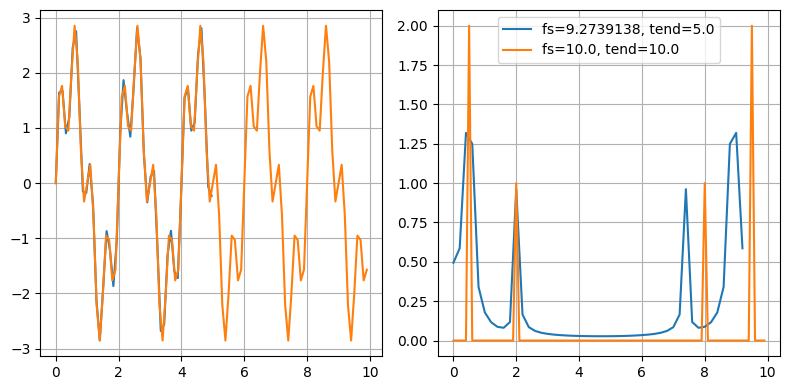

In [205]:
#> Raw Fourier transform
fig, ax = plt.subplots(1,2, figsize=(8,4))

for i, x in enumerate(xx):
  ax[0].plot(tt[i], xx[i])
  ax[1].plot(oo[i], np.abs(ff[i]), label=samplings[i]['label'])

ax[0].grid()
ax[1].grid()# ;#   ax[1].set_xlabel(f"$\omega$")
ax[1].legend()

fig.tight_layout()

## Aliasing

In [195]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt


#> Reference signal as a sum of harmonics
f1, f2 = 2.5, 0.5
phi1, phi2 = np.random.rand(), np.random.rand()
A1, A2 = 1., 2.

T1, T2 = 1/f1, 1/f2

x_fun = lambda t: A1*np.sin(2*np.pi*f1*t + phi1) + A2*np.sin(2*np.pi*f2*t + phi2)

print(f"Frequencies: {f1}, {f2}")
print(f"Periods    : {T1}, {T2}")


Frequencies: 2.5, 0.5
Periods    : 0.4, 2.0


In [187]:
samplings = [
    { 'fs': 10. , 'tend': 10. },
    { 'fs':  7. , 'tend': 10. },
    { 'fs':  4. , 'tend': 10. },
    { 'fs':  1.5, 'tend': 10. },
]

#> Add label to sampling dict, for plots
for s in samplings:
  s['label'] = f"fs={s['fs']}, tend={s['tend']}"


In [188]:
#> Check different samplings
xx, ff, tt, oo = [], [], [], []

max_om = 0. # for plot

for sampling in samplings:

  fs = sampling['fs']
  ts = 1 / fs
  tend = sampling['tend']

  t = np.arange(0, tend, ts)
  nt = len(t)

  #> Sampled signal
  x = x_fun(t)

  #> Fourier transform of the signal
  f = np.fft.fft(x) / nt * 2         # * ts for scaling, to get the actual amplitudes
  dom = 1. / tend
  om = np.arange(nt) * dom

  xx += [ x ]
  ff += [ f ]
  tt += [ t ]
  oo += [ om ]

  max_om = np.max([ max_om, nt * dom ])



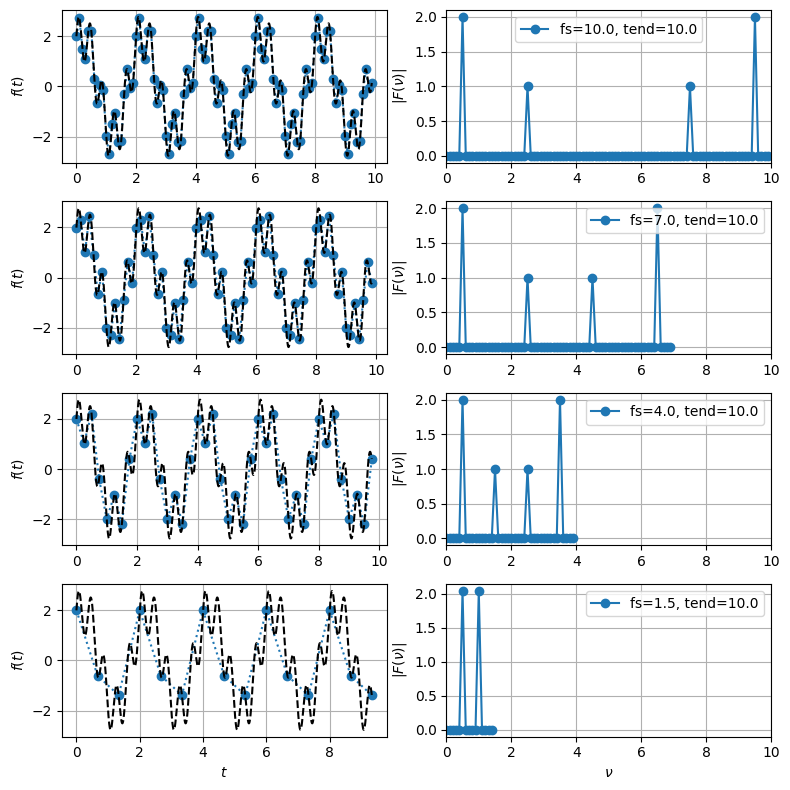

In [192]:
#> Raw Fourier transform
n_samplings = len(samplings)
fig, ax = plt.subplots(n_samplings,2, figsize=(8,2*n_samplings))

# max_om = np.max(np.array(oo))
dt_high_res = .001

for i, x in enumerate(xx):

  t_high_res = np.arange(0, tt[i][-1], dt_high_res)
  x_high_res = x_fun(t_high_res)

  ax[i,0].plot(tt[i], xx[i], ':o')
  ax[i,0].plot(t_high_res, x_high_res, '--', color='black')
  ax[i,1].plot(oo[i], np.abs(ff[i]), label=samplings[i]['label'], marker='o')

  ax[i,0].grid()
  ax[i,1].grid()# ;#   ax[1].set_xlabel(f"$\omega$")
  ax[i,1].set_xlim([0, max_om])
  ax[i,0].set_ylabel(r"$f(t)$")
  ax[i,1].set_ylabel(r"$|F(\nu)|$")

  ax[i,1].legend()


ax[n_samplings-1,0].set_xlabel(r"$t$")
ax[n_samplings-1,1].set_xlabel(r"$\nu$")


fig.tight_layout()

## Realizations of PSD

**Stationary stochastic signals.** For stationary stochastic signals, $PSD(\nu)$ is defined as the Fourier transform of it auto-correlation, i.e.

$$\Phi_{xx}(\nu) := \mathscr{F}\{ R_{xx} (\tau) \} (\nu) = \int_{t=-\infty}^{+\infty} R_{xx}(\tau) \,e^{-i \nu \tau} \, d \tau \ ,$$

with

$$R_{xx}(\tau) := \mathbb{E}\left[ x(t) x(t - \tau) \right] \ .$$

$$\begin{aligned}
  \Phi_{xx}(\nu)
  & = \int_{\tau = -\infty}^{+\infty} R_{xx}(\tau) e^{-i\nu \tau} d \tau = \\
  & = \int_{\tau = -\infty}^{+\infty} \mathbb{E}[x(t) x(t+\tau)] e^{-i \nu \tau} d \tau = \\
  & = \int_{\tau = -\infty}^{+\infty} \lim_{T \rightarrow + \infty} \int_{t=-T}^{T} x(t) x(t+\tau) \, dt \, e^{-i \nu \tau} d \tau = \\
  & = \int_{\tau = -\infty}^{+\infty} \lim_{T \rightarrow + \infty} \int_{t=-T}^{T} x(t) x(z) e^{-i \nu z} e^{i \nu t} d t dz = \\
  & = \left( \int_{\tau = -\infty}^{+\infty}  x(z) e^{-i \nu z}  dz \right) \left( \lim_{T \rightarrow + \infty} \int_{t=-T}^{T} x(t)e^{i \nu t} d t \right) = \\
  & = X(\nu) X^*(\nu) = \\
  & = \left| X(\nu) \right|^2 \ .
\end{aligned}$$

**todo** Is it possible to switch the expected value and integral operator?


**Periodic signals.** Let $f(t)$ a $T$-periodic signal. Its spectrum is discrete with **freqeuncy resolution** $\Delta \nu = \frac{1}{T}$. If $f(t)$ is discrete with sampling time $\Delta t$, its spectrum is $\nu_{s}$-periodic with **sampling frequency** $\nu_s = \frac{1}{\Delta t}$.


...



Here, given $PSD_x(\nu_k) := |X(\nu_k)|^2$, for all the avaliable frequencies, i.e.

$$\nu_k = k \nu_1 \ , \quad k = 0:N-1$$

with $\nu_1 = \frac{1}{T}$ frequency resolution, find a realization of the process in time domain.

**Remark.** In order to have a valid $PSD_x(\nu)$, this function needs to satisfy some conditions, as the elements of the DFT $X(\nu_k)$ needs to satisfy symmetry conditions to be the **transform of a real signal**.

* $X(0)$ is real

* symmetry for $k \ne 0$

  * If $N$ is even,

   $$\begin{aligned}
     X[k] & = X^*[N-k-1] \\
     X[N/2] & \in \mathbb{R}
   \end{aligned}$$

  * If $N$ is odd,

   $$X[k] = X^*[N-k]$$

### Exact realization

Frequency discretization of spectrum implies time discretization, as spectral resolution is the inverse of the sampling period, and maximum frequency (of the mirrored spectrum) is the inverse of the time-step.

In [2]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt


In [48]:
#> Time vector
dt, nt = .01, 1000

tv = np.arange(nt) * dt
tend = dt * nt

#> Frequency vector
df = 1. / tend
fv = np.arange(nt) * df


In [69]:
def psd_to_time_realization(psd_fun, fv, **params):
    """
    psd_fun(fv): function returning psd
    fv: vector of frequencies
    """
    N = len(fv)

    #> magnitude u(f;T) = |A(f;T)|^2 = A*(f;T) A(f;T)
    magnitude = np.sqrt(psd_fun(fv, **params))
    #> add random phase
    phase = np.exp(1j * np.random.uniform(0, 2*np.pi, N))
    # phase = np.zeros(N)
    spectrum = magnitude[1:] * phase[1:]
    #> Built a vector of transformed signal with the required symmetries to get a real ifft()
    xf = np.concatenate([ [magnitude[0]], spectrum, [magnitude[-1]], np.conj(spectrum[::-1]) ])
    xt = np.fft.ifft(xf)

    fmax = 2 * N * ( fv[1] - fv[0] )
    dt = 1. / fmax
    tv = np.arange(2*N)*dt

    return tv, xt


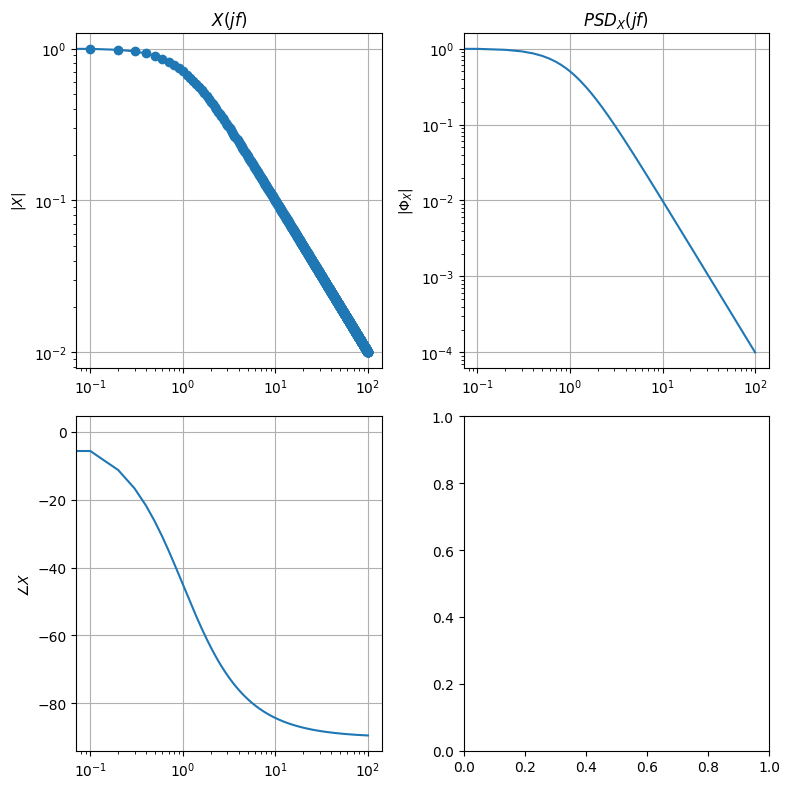

In [104]:
#> Fourier transform of the signal
"""
#> White noise approximation. Discretization sets the frequency resolution and the
# maximum frequency of the signal. With constant amplidute, this is a fmax-windowed
# and fs-sampled spectrum of a white noise.
tf_fun = lambda f: np.ones(np.shape(f))
"""
#> Low pass filter
tf_fun = lambda f: 1. / ( 1. + 1j * f )

"""
#> ~ Resonant system
# It has a prevailing harmonic content close to the "resonance", producing an
# "approximately harmonic" signal,
f_n, xi = 3., 0.01
tf_fun = lambda f: 1. / ( 1. + 2 * xi / f_n * 1j * f + ( (1j * f)/f_n )**2 )
"""
"""
#> ~ Resonant system + derivator
# It has a prevailing harmonic content close to the "resonance", producing an
# "approximately harmonic" signal,
f_n, xi = 3., 0.01
tf_fun = lambda f: 1j * f / ( 1. + 2 * xi / f_n * 1j * f + ( (1j * f)/f_n )**2 )
"""

#> PSD of the signal
psd_fun = lambda f: np.abs(tf_fun(f))**2

#> Plots of Fourier transform of the signal, and its PSD
tf_v = tf_fun(fv)
psd_v = tf_fun(fv) * np.conj(tf_fun(fv))

fig, ax = plt.subplots(2, 2, figsize=(8, 8))

ax[0,0].plot(fv, np.abs(tf_v), '-o')
ax[0,0].set_title(r"$X(j f)$")
ax[0,0].set_ylabel(r"$|X|$")
ax[0,0].set_xscale("log");  ax[0,0].set_yscale("log");  ax[0,0].grid()
ax[1,0].plot(fv, np.angle(tf_v) * 180/np.pi)
ax[1,0].set_ylabel(r"$\angle X$")
ax[1,0].set_xscale("log");  ax[1,0].grid()

ax[0,1].plot(fv, np.abs(psd_v))
ax[0,1].set_title(r"$PSD_X(j f)$")
ax[0,1].set_ylabel(r"$|\Phi_X|$")
ax[0,1].set_xscale("log");  ax[0,1].set_yscale("log");  ax[0,1].grid()

fig.tight_layout()

In [105]:
tv_real, xt_real = psd_to_time_realization(psd_fun, fv)

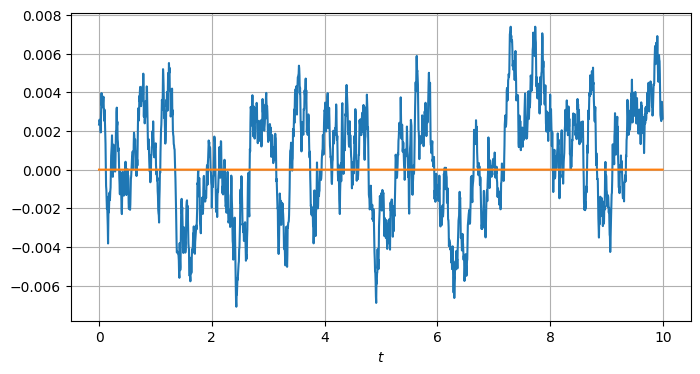

In [106]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))
ax.plot(tv_real, np.real(xt_real))
ax.plot(tv_real, np.imag(xt_real))
ax.set_xlabel(r"$t$")
ax.grid()

(None, <matplotlib.legend.Legend at 0x789bf5127a40>)

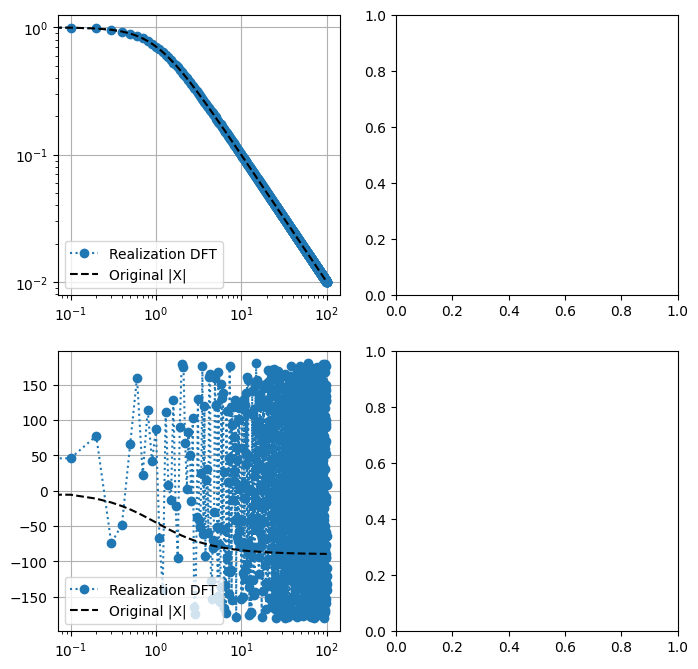

In [107]:
#> Check fft of the realized signal
xf_check = np.fft.fft(xt_real)

dt_real = tv_real[1] - tv_real[0]
tend_real = dt_real * len(tv_real)
fmax_real = 1 / dt_real
df_real = 1 / tend_real
fv_check = np.arange(len(tv_real)) * df_real

n_plot = len(tv_real) // 2

fig, ax = plt.subplots(2, 2, figsize=(8,8))
ax[0,0].plot(fv_check[:n_plot], np.abs(xf_check[:n_plot]), ':o', label="Realization DFT")
ax[0,0].plot(fv, np.abs(tf_v), '--', color="black", label="Original |X|")
ax[0,0].set_xscale("log");  ax[0,0].set_yscale("log");  ax[0,0].grid(), ax[0,0].legend()


ax[1,0].plot(fv_check[:n_plot], np.angle(xf_check[:n_plot]) * 180/np.pi, ':o', label="Realization DFT")
ax[1,0].plot(fv, np.angle(tf_v) * 180/np.pi, '--', color="black", label="Original |X|")
ax[1,0].set_xscale("log");  ax[1,0].grid(), ax[1,0].legend()


While magnitude is exactly represented in the realization of the PSD, it contains no information about the phase of the Fourier transform of the original signal, as $\Phi_X(f) = |X(f)|^2$.

## Shape filter



### Time-continuous domain

A shape filter usually takes a white noise $w$ as an input, to produce a

$$u(s) = G(s) w(s)$$

### Time-discrete domain



## Statistics of realizations

Given a PSD defined for $\omega \in [0, \omega_{max}]$, a realization has amplitude (equal for all the realizations)

$$|X_k(\omega)| = PSD_X^{1/2}(\omega)$$

and random phases $\phi_{kl}$ sampled for each $\omega_l \in [0, \omega_{max}]$ from a uniform probability distribution in $[-\pi, \pi]$, with probability density function

$$p(\phi) = \frac{1}{2 \pi} \ , \quad \text{for $\phi \in [-\pi, \pi]$}$$

 The $k^{th}$ realization at frequency $\omega_l$ has (discrete) spectrum

$$X_k(\omega_l) = \sqrt{PSD(\omega_l)} e^{i \phi_{kl}} \ ,$$

being $\phi_{kl}$ the arbitrary phase (no effect on the PSD) of the $l^{th}$ harmonics of the $k^{th}$ realization.

**Single realization.**
Spectrum and PSD of a realization

$$\begin{aligned}
X_k(\omega)
 & = \text{Re}\{ X_k(\omega) \} + i \text{Im}\{ X_k(\omega) \} = \\
 & = | X_k(\omega) | \, e^{i \angle X_k(\omega)}  = |X_k(\omega)| \cos \phi_{X_k}(\omega) + i |X_k(\omega)| \sin \phi_{X_k}(\omega) \\
PSD_{X_k}(\omega)
 & = |X_k(\omega)|^2 = X_k^*(\omega) X_k(\omega) = \left(  \text{Re}\{ X_k(\omega) \} \right)^2 + \left( \text{Im}\{ X_k(\omega) \} \right)^2 = PSD_{X}(\omega) \ ,
\end{aligned}$$

i.e. while every individual realization may have different values of real and imaginary parts (due to arbitrary phase), they all have the same PSD.

**Statistics of realizations.**

 - magnitude, deterministic not random

    $$|X(\omega)| = \sqrt{PSD(\omega)}$$

 - phase, uniform distribution for $\phi \in [-\pi,\pi]$
   - average value, variance (**does it have any meaning?**):
   
    $$\begin{aligned}
      \mathbb{E}[\phi] & = \int_{-\pi}^{\pi} \phi p(\phi) \, d \phi = 0 \\
      \mathbb{E}[\phi^2] & = 2\int_{0}^{\pi} p(\phi) \phi^2 \, d\phi = \frac{\pi^2}{3}
    \end{aligned}$$

 - real part and imaginary part

    
    $$\begin{aligned}
      \mathbb{E}[\text{Re}\{ X_k(\omega) \}] & = |X(\omega)| \int_{\phi=-\pi}^{\pi} p(\phi) \, \cos \phi \, d \phi = 0\\
      \mathbb{E}\left[\left( \text{Re}\{ X_k(\omega) \} \right)^2\right] & =  |X(\omega)|^2 \int_{-\pi}^{\pi} p(\phi) \cos^2 \phi \, d\phi = \frac{1}{2} |X(\omega)|^2 \\
      \mathbb{E}[\text{Im}\{ X_k(\omega) \}] & = 0 \\
      \mathbb{E}\left[\left(\text{Im}\{ X_k(\omega) \} \right)^2\right] & = \frac{1}{2} |X(\omega)|^2 \\
    \end{aligned}$$

    s.t.

    \begin{aligned}
      \mathbb{E}[X_k(\omega)] & = 0 \\
      \mathbb{E}[|X_k(\omega)|^2] & = \mathbb{E}\left[ \left(\text{Re}\{ X_k(\omega) \} \right)^2 + \left(\text{Im}\{ X_k(\omega) \} \right)^2 \right] = |X(\omega)|^2 = PSD(\omega) \ ,
    \end{aligned}

    as expected, as all the realizations come from the same PSD.

**Sample average** of $N$ i.i.d. realizations,

$$\overline{X}(\omega) = \frac{1}{N} \sum_{n=1}^N X_n(\omega)$$

- average

  $$\mathbb{E}\left[\overline{X}(\omega)\right] = 0$$

- PSD, "variance"

  $$\begin{aligned}
    \mathbb{E}\left[ \overline{X}^*(\omega) \overline{X}(\omega)  \right]
    & = \mathbb{E}\left[ \frac{1}{N} \sum_{n=1}^{N} {X_n}^*(\omega) \,  \frac{1}{N} \sum_{m=1}^{N} X_m(\omega)  \right] =  & \text{(i.i.d.)}\\
    & = \mathbb{E} \left[ \frac{1}{N^2} \sum_{n=1}^{N} |X_n|^2(\omega) \right] = \\
    & = \frac{1}{N} \mathbb{E} \left[ |X_k(\omega)|^2 \right]
  \end{aligned}$$

...

- Sum of (zero-average) independent spectra, $X_1(\omega)$, $X_2(\omega)$,...(it's not needed that they're identically distributed),

  $$S(\omega) := \sum_{n=1}^N X_n(\omega) \ .$$

  The average of the PSD of the sum of the spectra equals the sum of the average of the PSD of the spectra,

  $$\begin{aligned}
     \mathbb{E} \left[ \text{PSD}_S(\omega) \right]
     & := \mathbb{E} \left[ \left( \sum_{n=1}^{N} X_n(\omega) \right)^* \left( \sum_{m=1}^{N} X_m(\omega)  \right) \right] = & \text{(independent)} \\
     & = \sum_{n=1}^{N} \mathbb{E} \left[ | X_n(\omega) |^2 \right] = \\
     & = \sum_{n=1}^{N} \mathbb{E} \left[ PSD_{X_n}(\omega) \right] \ .
  \end{aligned}$$

<!--
- magnitude

- phase

- real and imaginary part

   \begin{aligned}
     \text{Re} \left\{ \overline{X}(\omega) \right\} & = \frac{1}{N} \sum_{n=1}^{N} \text{Re} \left\{ {X}_n(\omega) \right\} \\
     \text{Im} \left\{ \overline{X}(\omega) \right\} & = \frac{1}{N} \sum_{n=1}^{N} \text{Im} \left\{ {X}_n(\omega) \right\} \\
   \end{aligned}
-->